In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline

In [2]:
ROOT = Path.cwd().parent

# Load data
df = pd.read_excel(ROOT / 'data' / 'raw' / 'Telco_customer_churn.xlsx')

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


### Data Cleaning

In [3]:
df.shape

(7043, 33)

In [4]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['CustomerID'].duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [8]:
df[df['Churn Reason'].isnull()]['Churn Label'].value_counts()

Churn Label
No    5174
Name: count, dtype: int64

In [9]:
df.dtypes

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

In [10]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [11]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].value_counts())

C:\Users\computer complex\AppData\Local\Temp\ipykernel_3468\3104851729.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:



CustomerID:
CustomerID
3668-QPYBK    1
9237-HQITU    1
9305-CDSKC    1
7892-POOKP    1
0280-XJGEX    1
             ..
2569-WGERO    1
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

Country:
Country
United States    7043
Name: count, dtype: int64

State:
State
California    7043
Name: count, dtype: int64

City:
City
Los Angeles       305
San Diego         150
San Jose          112
Sacramento        108
San Francisco     104
                 ... 
Milford             4
Calpine             4
Standish            4
Tulelake            4
Olympic Valley      4
Name: count, Length: 1129, dtype: int64

Lat Long:
Lat Long
33.964131, -118.272783    5
34.059281, -118.30742     5
34.048013, -118.293953    5
34.062125, -118.315709    5
34.039224, -118.266293    5
                         ..
40.181279, -120.392967    4
39.672813, -120.456699    4
40.346634, -120.386422    4
41.813521, -121.492666    4
39.191797, -120.212401    4
Name: count, 

In [12]:
# Dropping columns that are non-informative or irrelevant for EDA and modeling:
# - Count: constant value of 1 across all 7043 rows, adds no information
# - Country: single value 'United States' across all rows
# - State: single value 'California' across all rows
# - Zip Code: too granular, high cardinality, not useful for EDA or modeling
# - Lat Long: combined string of Latitude and Longitude, redundant
# - Latitude & Longitude: geographic coordinates, not relevant for EDA or ML modeling

df.drop(columns=['Count', 'Country', 'State', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude'], inplace=True)

In [13]:
# Save processed file
df.to_csv(ROOT / 'data' / 'processed' / 'Telco_customer_churn_processed.csv', index=False)

## Exploratory Data Analysis (EDA)

In [15]:
df.columns

Index(['CustomerID', 'City', 'Gender', 'Senior Citizen', 'Partner',
       'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges',
       'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV',
       'Churn Reason'],
      dtype='str')

### Churn Analysis

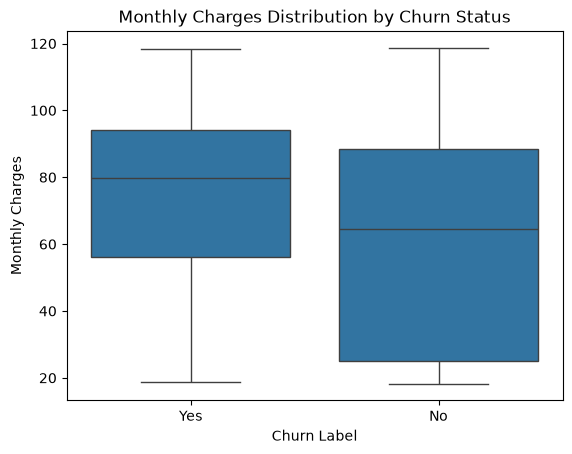

In [16]:
sns.boxplot(data=df, x='Churn Label', y='Monthly Charges')
plt.title('Monthly Charges Distribution by Churn Status')
plt.show()

In [17]:
df[df['Churn Label'] == 'Yes']['Monthly Charges'].max()

np.float64(118.35)

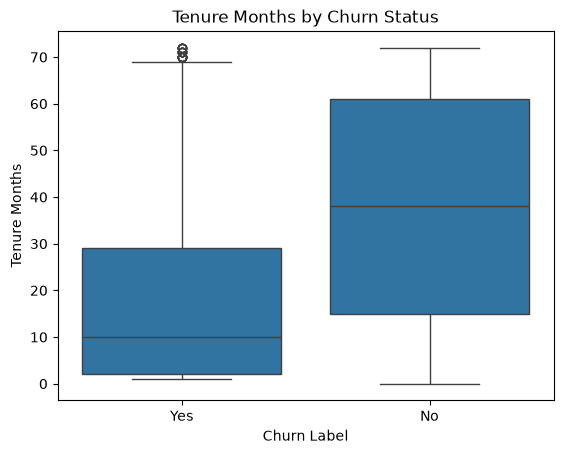

In [34]:
sns.boxplot(data=df, x='Churn Label', y='Tenure Months')
plt.title('Tenure Months by Churn Status')
plt.show()

In [15]:
# Total Charges contained 11 blank space values (" ") not detected during initial null check
# Discovered during EDA when attempting boxplot visualization
# Converted to numeric and filled with 0 as these correspond to Tenure Month = 0 customers

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(0)

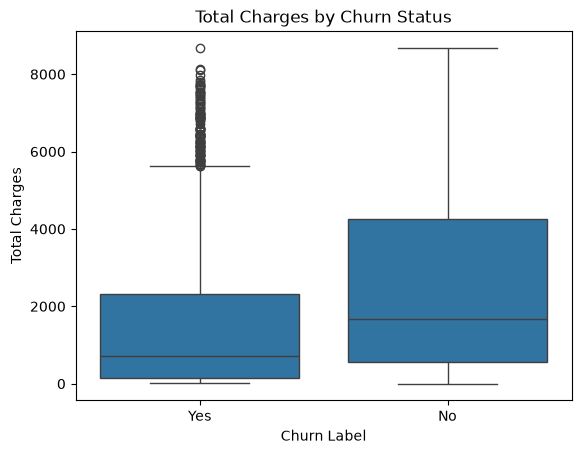

In [41]:
sns.boxplot(data=df, x='Churn Label', y='Total Charges')
plt.title('Total Charges by Churn Status')
plt.show()

Hoppers pay high monthly rates but leave early — resulting in low total revenue contribution despite being high monthly charge customers

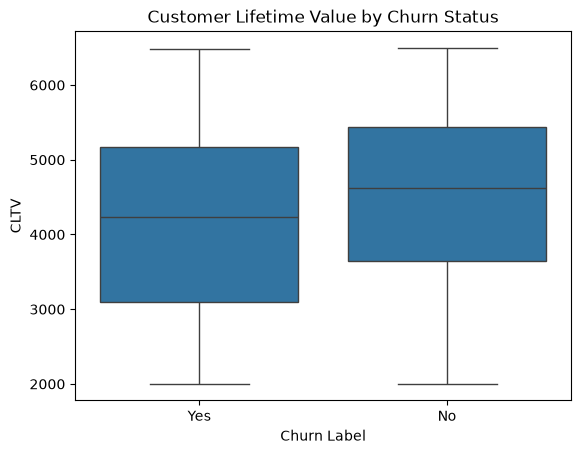

In [42]:
sns.boxplot(data=df, x='Churn Label', y='CLTV')
plt.title('Customer Lifetime Value by Churn Status')
plt.show()

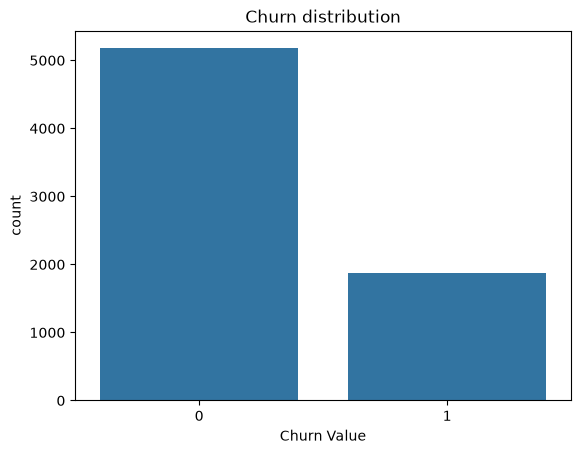

In [45]:
sns.countplot(data=df, x='Churn Value')
plt.title('Churn distribution')
plt.show()

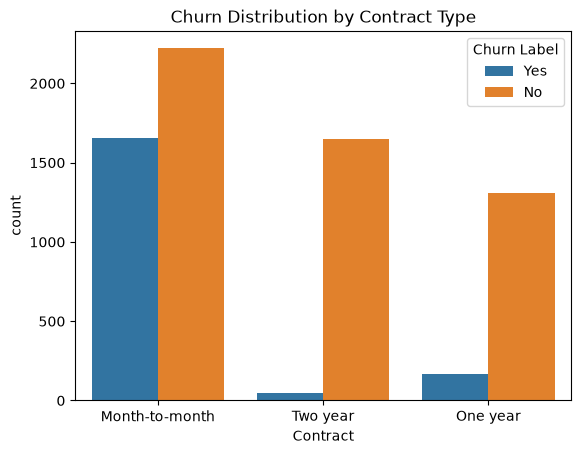

In [19]:
sns.countplot(data=df, x='Contract', hue='Churn Label')
plt.title('Churn Distribution by Contract Type')
plt.show()

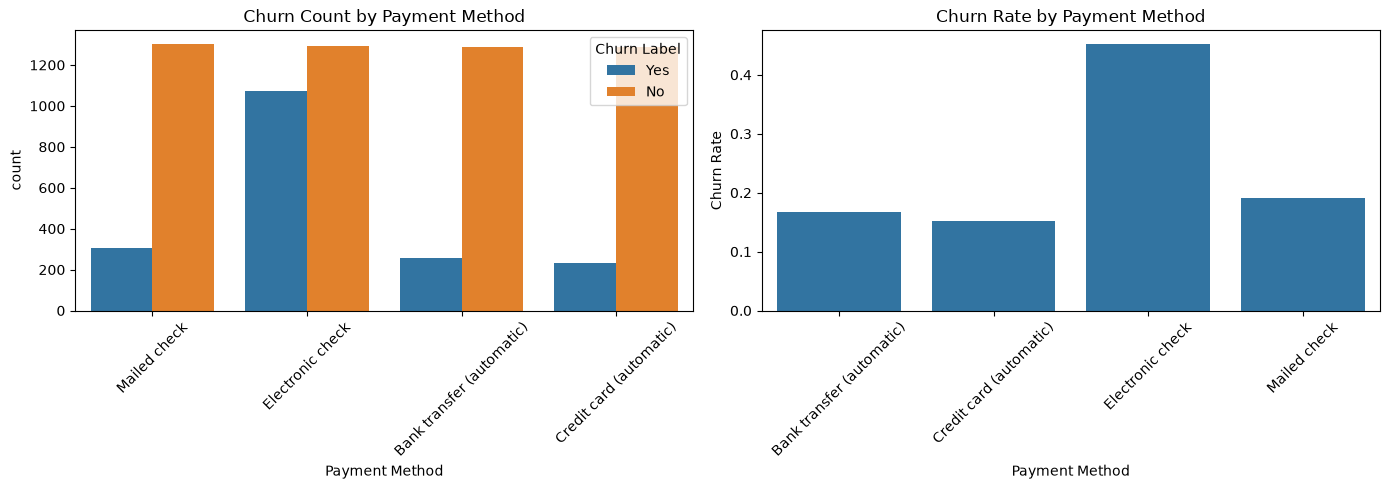

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='Payment Method', hue='Churn Label', ax=axes[0])
axes[0].set_title('Churn Count by Payment Method')
axes[0].tick_params(axis='x', rotation=45)

# Churn rate plot
churn_rate = df.groupby('Payment Method')['Churn Value'].mean().reset_index()
churn_rate.columns = ['Payment Method', 'Churn Rate']
sns.barplot(data=churn_rate, x='Payment Method', y='Churn Rate', ax=axes[1])
axes[1].set_title('Churn Rate by Payment Method')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

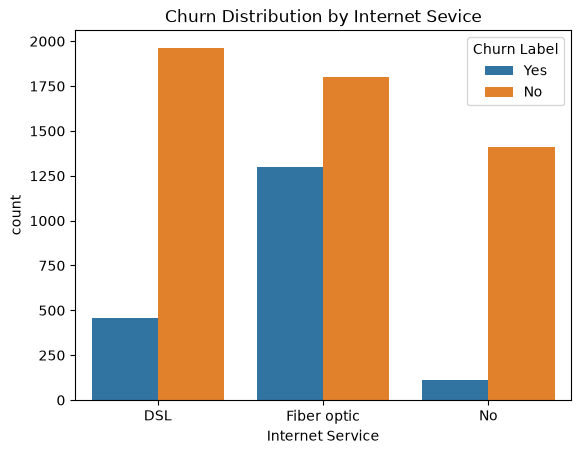

In [21]:
sns.countplot(data=df, x='Internet Service', hue='Churn Label')
plt.title('Churn Distribution by Internet Sevice')
plt.show()

Fiber optic customers on month-to-month contracts paying via electronic check are your highest churn risk

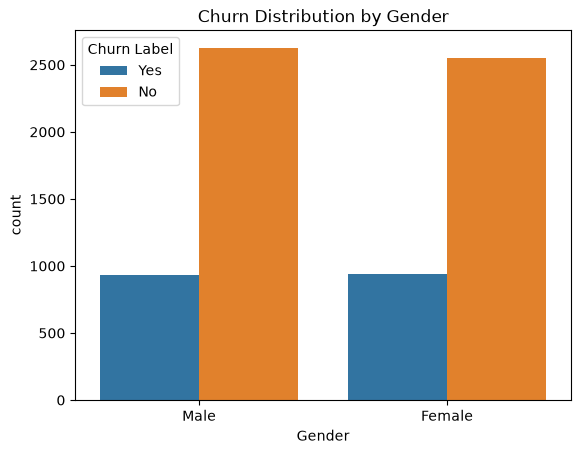

In [22]:
sns.countplot(data=df, x='Gender', hue='Churn Label')
plt.title('Churn Distribution by Gender')
plt.show()

Gender has no significant impact on churn — churn is evenly distributed across male and female customers.

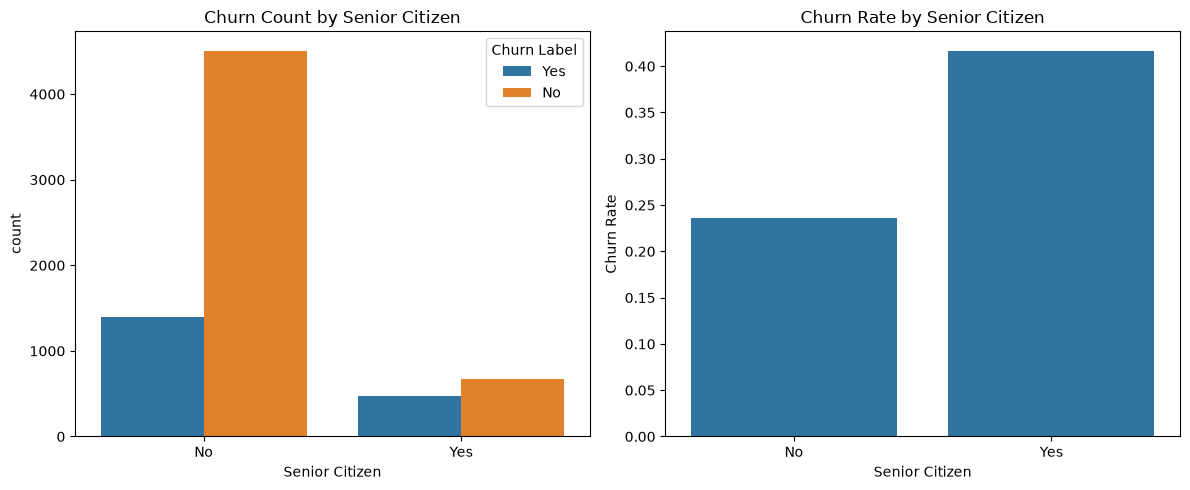

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(data=df, x='Senior Citizen', hue='Churn Label', ax=axes[0])
axes[0].set_title('Churn Count by Senior Citizen')

# Churn rate plot
churn_rate = df.groupby('Senior Citizen')['Churn Value'].mean().reset_index()
churn_rate.columns = ['Senior Citizen', 'Churn Rate']
sns.barplot(data=churn_rate, x='Senior Citizen', y='Churn Rate', ax=axes[1])
axes[1].set_title('Churn Rate by Senior Citizen')

plt.tight_layout()
plt.show()

Senior citizens are a small portion of customers but churn at nearly double the rate of non-senior citizens

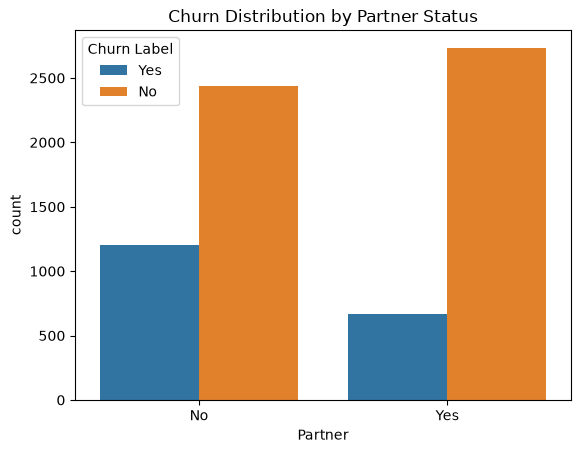

In [29]:
sns.countplot(data=df, x='Partner', hue='Churn Label')
plt.title('Churn Distribution by Partner Status')
plt.show()

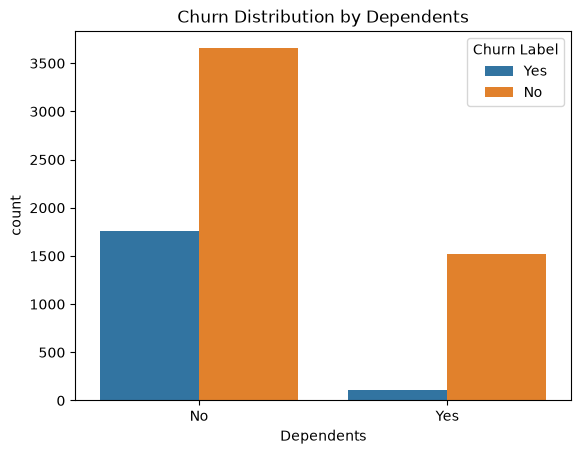

In [30]:
sns.countplot(data=df, x='Dependents', hue='Churn Label')
plt.title('Churn Distribution by Dependents')
plt.show()

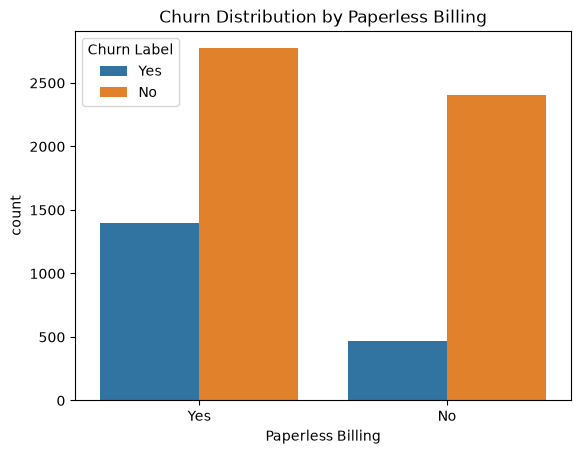

In [31]:
sns.countplot(data=df, x='Paperless Billing', hue='Churn Label')
plt.title('Churn Distribution by Paperless Billing')
plt.show()

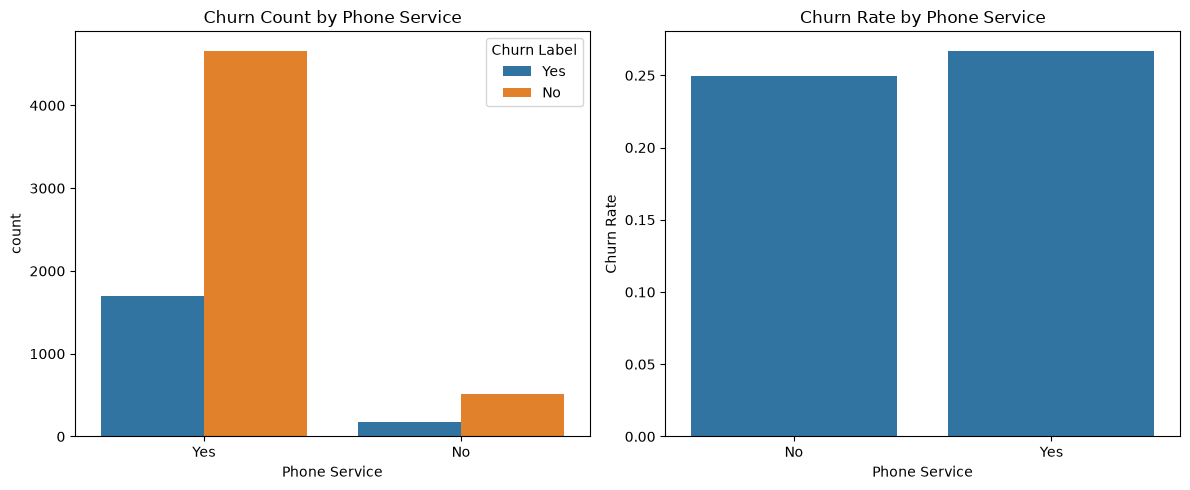

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='Phone Service', hue='Churn Label', ax=axes[0])
axes[0].set_title('Churn Count by Phone Service')

churn_rate = df.groupby('Phone Service')['Churn Value'].mean().reset_index()
churn_rate.columns = ['Phone Service', 'Churn Rate']
sns.barplot(data=churn_rate, x='Phone Service', y='Churn Rate', ax=axes[1])
axes[1].set_title('Churn Rate by Phone Service')

plt.tight_layout()
plt.show()

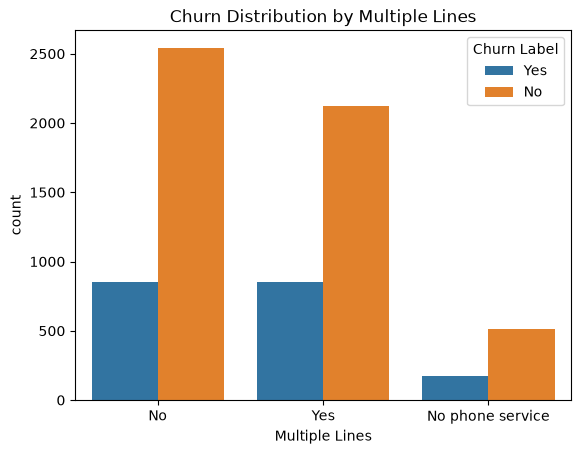

In [49]:
sns.countplot(data=df, x='Multiple Lines', hue='Churn Label')
plt.title('Churn Distribution by Multiple Lines')
plt.show()

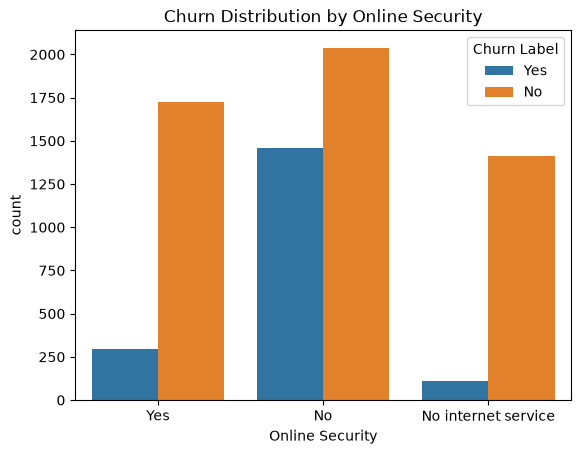

In [50]:
sns.countplot(data=df, x='Online Security', hue='Churn Label')
plt.title('Churn Distribution by Online Security')
plt.show()

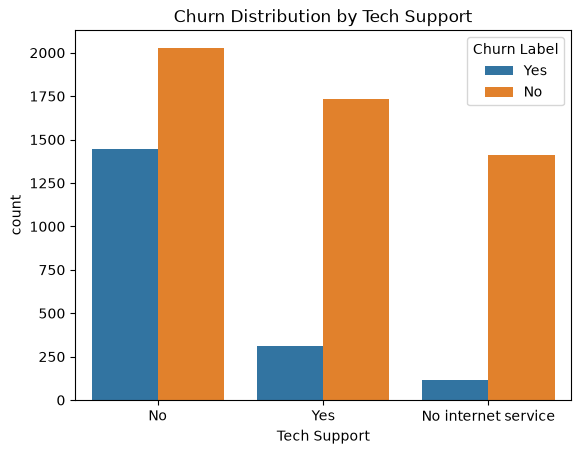

In [51]:
sns.countplot(data=df, x='Tech Support', hue='Churn Label')
plt.title('Churn Distribution by Tech Support')
plt.show()

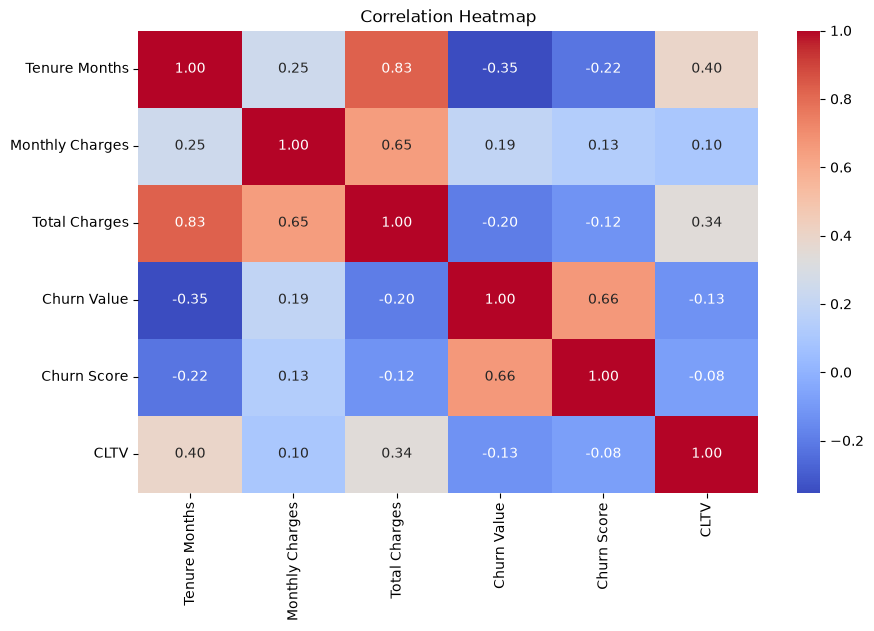

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

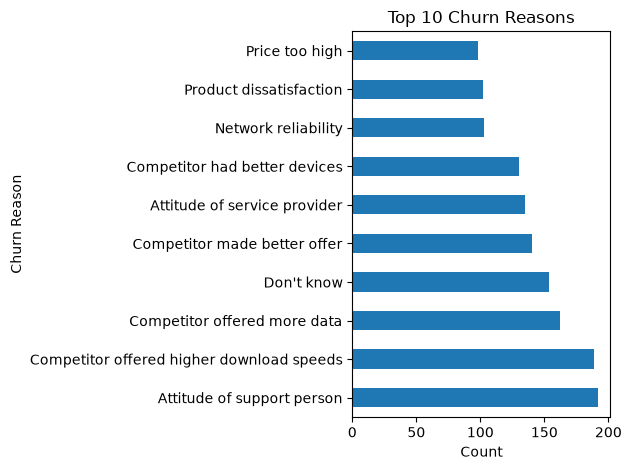

In [52]:
df['Churn Reason'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Churn Reasons')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

## EDA Summary — Churn Analysis

### Dataset Overview
- Total customers: 7,043 | Churned: ~1,869 (26%) | Retained: ~5,174 (74%)
- Class imbalance is moderate and will be addressed during modeling

### Key Churn Drivers

**Contract Type**
- Month-to-month customers have the highest churn count by far
- One and two year contract customers rarely churn due to long term commitment

**Monthly Charges**
- Churned customers have a higher median monthly charge (~79) vs retained (~62)
- Higher charges on flexible contracts create strong incentive to switch providers

**Tenure Months**
- Churned customers have significantly lower tenure — newer customers are more likely to leave
- Long term customers build loyalty and rarely churn (confirmed by -0.35 correlation with Churn Value)

**Internet Service**
- Fiber optic customers churn the most — premium service with highest monthly charges
- Customers with no internet service barely churn — low cost, low dissatisfaction

**Online Security & Tech Support**
- Customers without online security churn at ~41% vs only ~15% for those with it
- Customers without tech support churn at ~41% vs ~15% for those with it
- Customers who invest in add-on services are significantly more committed and loyal
- Lack of support and security features indicates bare minimum plans — easier to leave
- Both are strong churn predictors and will be included in modeling

**Payment Method**
- Electronic check users have the highest churn rate
- Automatic payment methods (credit card, bank transfer) correlate with lower churn — more committed customers

**Paperless Billing**
- Paperless billing customers churn more — digitally engaged and price aware, more likely to compare and switch

**Demographics**
- Gender has no impact on churn — evenly distributed across male and female
- Senior citizens churn at nearly double the rate (~45%) despite being a small portion of customers
- Customers without a partner or dependents churn significantly more — less financial commitment and easier to switch

**Total Charges & CLTV**
- Churned customers have low total charges despite high monthly charges — confirming short tenure
- CLTV shows marginal difference and is a derived metric — excluded from modeling to avoid leakage

### High Risk Customer Profile
> "A new fiber optic customer on a month-to-month contract, paying via electronic check,
> enrolled in paperless billing, with no partner or dependents — is your highest churn risk"

### Features Dropped Before Modeling
- Gender: no predictive value
- Churn Score, CLTV, Churn Reason, Churn Label: data leakage or redundancy

### Correlation Highlights
- Tenure Months & Total Charges: strong positive (0.83) — multicollinearity risk
- Churn Score & Churn Value: strong positive (0.66) — confirms leakage
- Tenure Months & Churn Value: negative (-0.35) — longer tenure = lower churn risk